# ADInt Explorer — Reviewer-Runnable Version

**Author**: Aviral Bhatnagar · HINF 5620 final project · University of Minnesota

This notebook runs the ADInt Explorer Dash app inside Google Colab using a
Drive-mounted copy of the Zhang lab's ADInt knowledge graph data.

## Reviewer setup

1. Download `ADIntKG.tsv` and `Neo4j_data/neo4j_node_updated.csv` from
   [github.com/zhang-informatics/ADInt](https://github.com/zhang-informatics/ADInt)
2. Place both files in a folder on your Google Drive
3. Mount Drive (Section 1) and update `DATA_DIR` (Section 2) to your folder path
4. Run sections 1–11 in order. Section 11 launches the live app and prints a
   clickable URL that opens the dashboard in your browser.

---

## Table of Contents

1. [Importing Libraries](#1-importing-libraries)
2. [Configuration: Drive Path, Constants & Colors](#2-configuration-drive-path-constants--colors)
3. [Loading the Data Files](#3-loading-the-data-files)
4. [Classifying Nodes by Category](#4-classifying-nodes-by-category)
5. [Building the NetworkX Graph & Evidence Index](#5-building-the-networkx-graph--evidence-index)
6. [Exploring the Knowledge Graph Structure](#6-exploring-the-knowledge-graph-structure)
   - [6.1 Degree Distribution by Category](#61-degree-distribution-by-category)
   - [6.2 Alzheimer's Edge Composition by Predicate](#62-alzheimers-edge-composition-by-predicate)
7. [Helper Functions: Layout, Search & Path Finding](#7-helper-functions-layout-search--path-finding)
8. [Stylesheet: Visual Rules for the Graph](#8-stylesheet-visual-rules-for-the-graph)
9. [App Layout: Sidebar Controls & Graph Canvas](#9-app-layout-sidebar-controls--graph-canvas)
10. [Callbacks: Reactive Logic](#10-callbacks-reactive-logic)
11. [Launching the App](#11-launching-the-app)

# 1. Importing Libraries

In [ ]:
! pip install dash
! pip install dash_cytoscape
from __future__ import annotations
import numpy as np
import math
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import dash
import dash_cytoscape as cyto
import networkx as nx
from collections import defaultdict
import pandas as pd
from dash import Input, Output, State, callback_context, dcc, html, no_update

# 2. Configuration: Drive Path, Constants & Colors

In [2]:
# REVIEWERS: change this to wherever you put the data on your Drive(Both ADIntKG.tsv and Neo4j_data/neo4j_node_updated.csv must be inside)

DATA_DIR = Path('/content/drive/MyDrive/ADInt KG')

# Constants
ALZHEIMERS_CUI = "C0002395"
PER_CATEGORY_TOP_K = 7  # neighbors shown PER category around the focal node (all 7 categories appear)
SEARCH_DROPDOWN_LIMIT = 7000  # While there are 162K entitities, the dropdown limit is capped to avoid latency during app operations. If the dropdown is too laggy, please reduce this number to anywhere from 2000 to 5000
# Note: Only the dropdown options are capped. The app still works with the entire dataset.

# Colors
CATEGORY_COLORS = {
    "Drug":                                  "#EC993F",
    "Dietary Supplement":                    "#6FBF73",
    "Complementary and Integrative Health":  "#2CA6A4",
    "Disease or Syndrome":                   "#E5736A",
    "Gene or Genome":                        "#4A7FD6",
    "Organism Function":                     "#9B59B6",
    "Other":                                 "#B0B0B0",
}

# 3. Loading Data Files

In [3]:
print("Loading ADIntKG.tsv ...")
edges_df = pd.read_csv(DATA_DIR / "ADIntKG.tsv", sep="\t")
print(f"  {len(edges_df):,} evidence rows (PMID-level)")

print("Loading node table (neo4j_node_updated.csv) ...")
nodes_df = pd.read_csv(DATA_DIR / "Neo4j_data" / "neo4j_node_updated.csv")
print(f"  {len(nodes_df):,} typed concepts")

Loading ADIntKG.tsv ...
  1,294,814 evidence rows (PMID-level)
Loading node table (neo4j_node_updated.csv) ...
  162,212 typed concepts


# 4. Classifying Nodes by Category

In [4]:

def classify(category: str, semtype: str, label: str) -> str:
    """Resolve a concept to one of the 7 display categories.

    Rules are evaluated top-down. The first match wins. The Category column
    explicitly tags the dietary-supplement and CIH vocabularies and everything
    else falls through to UMLS Semantic_Type / Label inspection.
    """
    if category == "Complementary and Integrative Health":
        return "Complementary and Integrative Health"
    if category == "Dietary Supplement":
        return "Dietary Supplement"
    if semtype == "Disease or Syndrome":
        return "Disease or Syndrome"
    if semtype == "Gene or Genome":
        return "Gene or Genome"
    if semtype == "Organism Function":
        return "Organism Function"
    if label == "Chemicals & Drugs":
        return "Drug"
    return "Other"


nodes_df["display_category"] = [
    classify(c, s, l)
    for c, s, l in zip(nodes_df["Category"], nodes_df["Semantic_Type"], nodes_df["Label"])
]
cui_to_name = dict(zip(nodes_df["CUI"], nodes_df["Name"]))
cui_to_category = dict(zip(nodes_df["CUI"], nodes_df["display_category"]))
cui_to_semtype = dict(zip(nodes_df["CUI"], nodes_df["Semantic_Type"]))

# 5. Building the NetworkX Graph & Evidence Index

In [5]:
print("Building NetworkX graph + directed predicate index ...")
# Dropping duplicate to one row per (S, P, O) directed triple
triples_df = edges_df[["SUBJECT_CUI", "PREDICATE", "OBJECT_CUI"]].drop_duplicates()

# Dropping self-loops
triples_df = triples_df[triples_df["SUBJECT_CUI"] != triples_df["OBJECT_CUI"]]
print(f"  {len(triples_df):,} unique directed triples")

# Undirected NetworkX graph for path-finding (direction doesn't matter for chain discovery)
G = nx.from_pandas_edgelist(
    triples_df, source="SUBJECT_CUI", target="OBJECT_CUI", create_using=nx.Graph
)
print(f"  {G.number_of_nodes():,} nodes / {G.number_of_edges():,} unique undirected edges")

# Directed predicate index. It preserves the original (S → O) direction of each predicate
# so the visualization can show arrows correctly (come back to this). Keyed by (subject, object).

edge_predicates: dict[tuple[str, str], list[str]] = defaultdict(list)
for s, p, o in zip(triples_df["SUBJECT_CUI"], triples_df["PREDICATE"], triples_df["OBJECT_CUI"]):
    edge_predicates[(s, o)].append(p)
print(f"  directed predicate index: {len(edge_predicates):,} (S, O) keys")

# Index evidence rows by (subject, predicate, object) for the evidence panel
evidence_index = edges_df.groupby(["SUBJECT_CUI", "PREDICATE", "OBJECT_CUI"])

Building NetworkX graph + directed predicate index ...
  949,764 unique directed triples
  162,211 nodes / 742,274 unique undirected edges
  directed predicate index: 906,767 (S, O) keys


# 6. Exploring the Knowledge Graph Structure

Before building the interactive app, two visualizations help us understand
the data's shape, and motivate the design choices that come next.

## 6.1 Degree Distribution by Category

A log-scale box plot showing how many connections each node has, grouped
by category. The Alzheimer's Disease outlier at degree 8,394 motivates
the focal-node paradigm.

/tmp/ipykernel_32766/1618428353.py:29: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_32766/1618428353.py:51: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



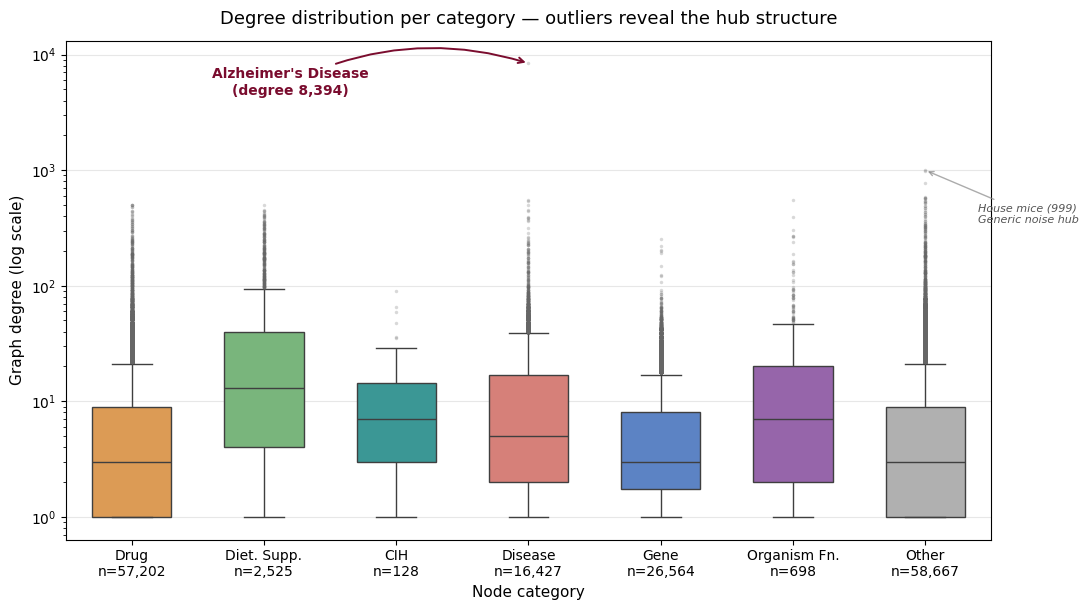

In [19]:

records = [{"category": cui_to_category.get(n, "Other"), "degree": G.degree(n)}
           for n in G.nodes()]
df = pd.DataFrame(records)

# Plot log-scale box plot with colors
CATEGORY_COLORS = {
    "Drug":                                  "#F39C3E",
    "Dietary Supplement":                    "#6FBF73",
    "Complementary and Integrative Health":  "#2CA6A4",
    "Disease or Syndrome":                   "#E5736A",
    "Gene or Genome":                        "#4A7FD6",
    "Organism Function":                     "#9B59B6",
    "Other":                                 "#B0B0B0",
}
SHORT = {
    "Complementary and Integrative Health": "CIH",
    "Dietary Supplement":                   "Diet. Supp.",
    "Disease or Syndrome":                  "Disease",
    "Gene or Genome":                       "Gene",
    "Organism Function":                    "Organism Fn.",
}
df["short_cat"] = df["category"].map(lambda c: SHORT.get(c, c))
order_full   = list(CATEGORY_COLORS.keys())
order_short  = [SHORT.get(c, c) for c in order_full]
palette      = [CATEGORY_COLORS[c] for c in order_full]

counts = df["category"].value_counts().to_dict()
plt.figure(figsize=(11, 6.2))
ax = sns.boxplot(
    data=df, x="short_cat", y="degree",
    order=order_short, palette=palette,
    showfliers=True,                      # turn outliers ON
    fliersize=2.5,                         # small dots, not big circles
    flierprops=dict(marker="o",
                    markerfacecolor="#666",
                    markeredgecolor="none",
                    alpha=0.25),           # semi-transparent
    width=0.6,
)
ax.set_yscale("log")
ax.set_xlabel("Node category", fontsize=11)
ax.set_ylabel("Graph degree (log scale)", fontsize=11)
ax.set_title("Degree distribution per category — outliers reveal the hub structure",
             fontsize=13, pad=12)
ax.grid(axis="y", alpha=0.3)
ax.set_axisbelow(True)

# Node count annotations under each x-label
new_labels = [f"{order_short[i]}\nn={counts.get(order_full[i], 0):,}"
              for i in range(len(order_full))]
ax.set_xticklabels(new_labels, fontsize=10)

# Annotate the most important outlier: Alzheimer's Disease at 8,394 ---
disease_x = order_short.index("Disease")
ax.annotate(
    "Alzheimer's Disease\n(degree 8,394)",
    xy=(disease_x, 8394),
    xytext=(disease_x - 1.8, 4500),
    fontsize=10, fontweight="bold", color="#7A0C2E",
    ha="center",
    arrowprops=dict(arrowstyle="->", color="#7A0C2E", lw=1.4,
                    connectionstyle="arc3,rad=-0.2"),
)

other_x = order_short.index("Other")
ax.annotate(
    "House mice (999)\nGeneric noise hub",
    xy=(other_x, 999),
    xytext=(other_x + 0.4, 350),
    fontsize=8, color="#555", style="italic",
    ha="left",
    arrowprops=dict(arrowstyle="->", color="#888", lw=1, alpha=0.7),
)

plt.tight_layout()

out = Path(DATA_DIR) / "fig_degree_by_category_with_outliers.png"
plt.show()

## 6.2 Alzheimer's Edge Composition by Predicate

A stacked horizontal bar chart breaking down all 15,153 edges connecting
AD to other concepts, by predicate type and neighbor category. Reveals
that PREVENTS edges are sparse (~4%) and CIH neighbors are nearly
invisible — both findings shape the tool's design.

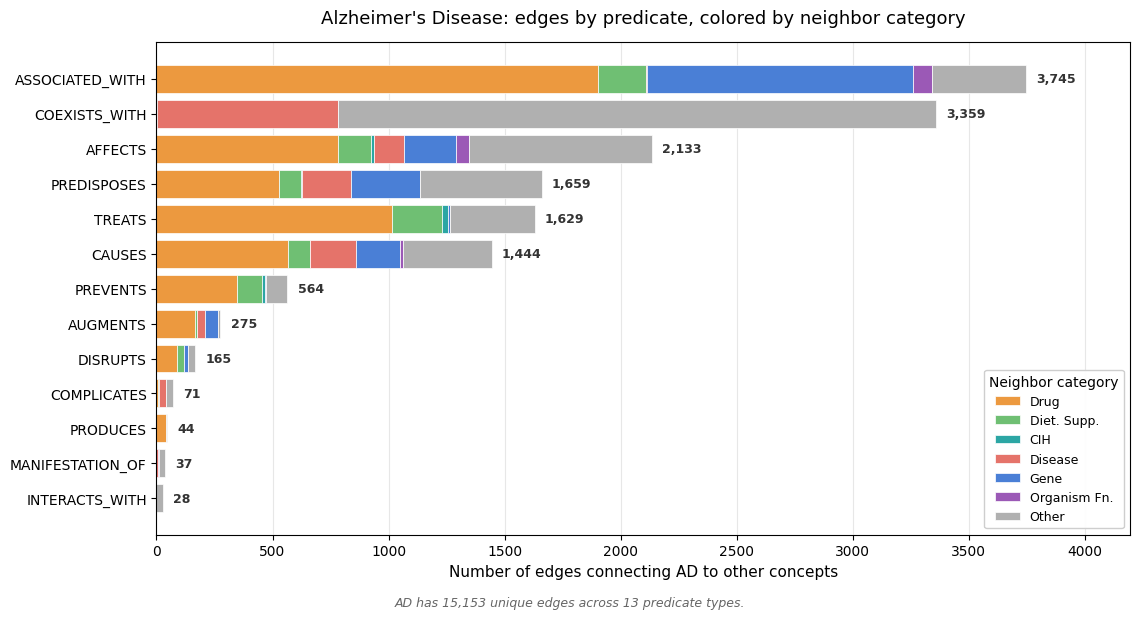

In [20]:
ALZHEIMERS_CUI = "C0002395"

# 1. Filter the edges DataFrame to triples where AD is subject or object
ad_edges = edges_df[
    (edges_df["SUBJECT_CUI"] == ALZHEIMERS_CUI) |
    (edges_df["OBJECT_CUI"] == ALZHEIMERS_CUI)
].drop_duplicates(subset=["SUBJECT_CUI", "PREDICATE", "OBJECT_CUI"])

# 2. For each AD edge, find the OTHER endpoint and its category
def other_endpoint(row):
    return row["OBJECT_CUI"] if row["SUBJECT_CUI"] == ALZHEIMERS_CUI else row["SUBJECT_CUI"]

ad_edges = ad_edges.copy()
ad_edges["other_cui"] = ad_edges.apply(other_endpoint, axis=1)
ad_edges["other_cat"] = ad_edges["other_cui"].map(lambda c: cui_to_category.get(c, "Other"))

# 3. Count edges per (predicate, category)
counts = ad_edges.groupby(["PREDICATE", "other_cat"]).size().unstack(fill_value=0)

# 4. Order predicates by total count (most common at top)
counts["TOTAL"] = counts.sum(axis=1)
counts = counts.sort_values("TOTAL", ascending=True)
totals = counts.pop("TOTAL")

# 5. Order categories using Zhang lab convention
CATEGORY_COLORS = {
    "Drug":                                  "#EC993F",
    "Dietary Supplement":                    "#6FBF73",
    "Complementary and Integrative Health":  "#2CA6A4",
    "Disease or Syndrome":                   "#E5736A",
    "Gene or Genome":                        "#4A7FD6",
    "Organism Function":                     "#9B59B6",
    "Other":                                 "#B0B0B0",
}
cat_order = [c for c in CATEGORY_COLORS if c in counts.columns]
counts = counts[cat_order]

# 6. Plot — horizontal stacked bar
fig, ax = plt.subplots(figsize=(11.5, 6))
left = np.zeros(len(counts))
SHORT = {
    "Complementary and Integrative Health": "CIH",
    "Dietary Supplement": "Diet. Supp.",
    "Disease or Syndrome": "Disease",
    "Gene or Genome": "Gene",
    "Organism Function": "Organism Fn.",
}
for cat in cat_order:
    short = SHORT.get(cat, cat)
    ax.barh(counts.index, counts[cat], left=left,
            color=CATEGORY_COLORS[cat], label=short, edgecolor="white", linewidth=0.5)
    left += counts[cat].values

# 7. Annotate totals at the right of each bar
for i, predicate in enumerate(counts.index):
    total = int(totals.loc[predicate])
    ax.text(total + max(totals) * 0.012, i, f"{total:,}",
            va="center", fontsize=9, color="#333", fontweight="bold")

ax.set_xlabel("Number of edges connecting AD to other concepts", fontsize=11)
ax.set_title("Alzheimer's Disease: edges by predicate, colored by neighbor category",
             fontsize=13, pad=14)
ax.legend(loc="lower right", fontsize=9, framealpha=0.95, title="Neighbor category")
ax.grid(axis="x", alpha=0.3)
ax.set_axisbelow(True)
ax.set_xlim(0, max(totals) * 1.12)

# Footer
fig.text(0.5, -0.02,
         f"AD has {len(ad_edges):,} unique edges across {ad_edges['PREDICATE'].nunique()} predicate types.",
         ha="center", fontsize=9, style="italic", color="#666")
plt.tight_layout()

out = Path(DATA_DIR) / "fig_ad_neighborhood_structure.png"

plt.show()

# 7. Helper Functions: Layout, Search & Path Finding

In [6]:
def display_label(name: str, category: str) -> str:
    """Strip the noisy '|alias' suffix from UMLS preferred names.

    Many ADInt concept names embed multiple aliases separated by '|':
      - Genes: "EDN1 gene|EDN1"               → "EDN1"           (HGNC symbol)
      - Drugs: "Protein S100-A9|S100A9"       → "Protein S100-A9" (chemical name)
      - Other: pick the shortest non-empty token (usually the symbol/abbrev)

    The full name is preserved in cui_to_name for the search dropdown and
    evidence panel — only the on-graph label is shortened.
    """
    if not isinstance(name, str) or "|" not in name:
        return name
    parts = [p.strip() for p in name.split("|") if p.strip()]
    if not parts:
        return name
    if category == "Gene or Genome":
        return parts[-1]   # HGNC symbol is the last token
    if category == "Drug":
        return parts[0]    # chemical name is the first token
    return min(parts, key=len)


def top_neighbors(cui: str, k: int) -> list[str]:
    """Return up to k neighbors of `cui`, ranked by degree (most connected first)."""
    if cui not in G:
        return []
    nbrs = sorted(G.neighbors(cui), key=lambda n: G.degree(n), reverse=True)
    return nbrs[:k]


def stratified_neighbors(focal_cui: str, k_per_category: int = PER_CATEGORY_TOP_K) -> list[str]:
    """Return [focal_cui] + top-k highest-degree neighbors
    This guarantees CIH, Gene or Genome, Organism Function, etc. are represented
    in the default view even though their absolute degrees are lower than the
    dominant Drug/Disease/Other concepts. Matches ADInt's intervention-centric
    research narrative — the whole point is to surface CIH and supplement candidates.
    """
    if focal_cui not in G:
        return [focal_cui]
    by_cat: dict[str, list[tuple[str, int]]] = defaultdict(list)
    for n in G.neighbors(focal_cui):
        cat = cui_to_category.get(n, "Other")
        by_cat[cat].append((n, G.degree(n)))
    selected = [focal_cui]
    for cat in CATEGORY_COLORS:  # iterate in declared order so colors are balanced
        nbrs = sorted(by_cat.get(cat, []), key=lambda x: x[1], reverse=True)
        selected.extend([n for n, _ in nbrs[:k_per_category]])
    return selected


def shortest_path(start: str, end: str) -> list[str]:
    """Shortest undirected path between two CUIs, or [] if none exists."""
    try:
        return nx.shortest_path(G, start, end)
    except (nx.NetworkXNoPath, nx.NodeNotFound):
        return []


def compute_positions(visible_cuis, focal_cui, radius: float = 360.0):
    """Place focal at (0, 0) and arrange neighbors in a single ring, grouped
    by category in equal-size pie-slice wedges.

    Each present category gets the same angular share, regardless of how many
    nodes it has — this gives every category equal visual weight, so rare
    categories like CIH or Organism Function are not crushed into a sliver.
    Within a wedge, nodes are placed evenly along an arc, sorted by degree
    (most connected → outermost ends of the wedge).
    """
    positions: dict[str, dict[str, float]] = {focal_cui: {"x": 0.0, "y": 0.0}}

    by_cat: dict[str, list[str]] = defaultdict(list)
    for cui in visible_cuis:
        if cui == focal_cui:
            continue
        cat = cui_to_category.get(cui, "Other")
        by_cat[cat].append(cui)

    # Iterate categories in declared order so colors are evenly distributed
    # around the wheel — Drug at top, then Dietary Supplement, CIH, ... clockwise.
    present_cats = [c for c in CATEGORY_COLORS if by_cat.get(c)]
    if not present_cats:
        return positions

    wedge_size = 2 * math.pi / len(present_cats)
    angle = -math.pi / 2  # start at the top of the circle

    for cat in present_cats:
        nodes = sorted(by_cat[cat], key=lambda n: G.degree(n), reverse=True)
        if len(nodes) == 1:
            theta = angle + wedge_size / 2
            positions[nodes[0]] = {
                "x": radius * math.cos(theta),
                "y": radius * math.sin(theta),
            }
        else:
            padding = 0.18  # leave a gap between adjacent wedges
            for i, cui in enumerate(nodes):
                t = padding + (1 - 2 * padding) * (i / (len(nodes) - 1))
                theta = angle + t * wedge_size
                positions[cui] = {
                    "x": radius * math.cos(theta),
                    "y": radius * math.sin(theta),
                }
        angle += wedge_size

    return positions


def build_elements(visible_cuis, focal_cui, hidden_categories, path, focal_only_edges):
    """Construct Cytoscape elements with category-wedge positions, edge
    aggregation, and an optional focal-only edge filter.

    Edges are aggregated by direction: a single (source → target) edge
    carries the full list of predicates between that pair (so 5 parallel
    arrows collapse into 1 edge with `count: 5`). The forward and reverse
    directions are kept as separate edges so direction is still legible.

    When `focal_only_edges` is True, only edges that touch the focal node
    are emitted (path edges are always emitted regardless, so the gold chain
    is never hidden).
    """
    # Path edges as ordered pairs for fast membership tests during edge emission.
    path_pairs = set()
    for i in range(len(path) - 1):
        a, b = path[i], path[i + 1]
        path_pairs.add((a, b))
        path_pairs.add((b, a))
    path_set = set(path)

    # Filter visible nodes by category checklist (focal + path nodes always survive).
    visible_after_filter = []
    for cui in visible_cuis:
        cat = cui_to_category.get(cui, "Other")
        if cat in hidden_categories and cui != focal_cui and cui not in path_set:
            continue
        visible_after_filter.append(cui)

    positions = compute_positions(visible_after_filter, focal_cui)

    nodes = []
    for cui in visible_after_filter:
        cat = cui_to_category.get(cui, "Other")
        full_name = cui_to_name.get(cui, cui)
        nodes.append({
            "data": {
                "id": cui,
                "label": display_label(full_name, cat),
                "full_name": full_name,
                "category": cat,
                "semtype": cui_to_semtype.get(cui, "?"),
                "is_focal": cui == focal_cui,
                "is_path": cui in path_set,
            },
            "position": positions.get(cui, {"x": 0.0, "y": 0.0}),
        })

    # Aggregate edges: one edge per (source, target) direction, carrying the
    # full list of predicates for that pair. Forward and reverse are separate.
    visible_set = {n["data"]["id"] for n in nodes}
    visible_list = list(visible_set)
    edges = []

    def emit(u: str, v: str, predicates: list[str]):
        is_path = (u, v) in path_pairs
        # If focal-only is on, skip cross-links unless they're path edges.
        if focal_only_edges and not is_path and focal_cui not in (u, v):
            return
        count = len(predicates)
        first = predicates[0]
        label = first if count == 1 else f"{first} (+{count - 1})"
        edges.append({
            "data": {
                "source": u,
                "target": v,
                "label": label,
                "predicates": predicates,
                "count": count,
                "is_path": is_path,
            }
        })

    for i, u in enumerate(visible_list):
        for v in visible_list[i + 1:]:
            forward = edge_predicates.get((u, v))
            if forward:
                emit(u, v, forward)
            reverse = edge_predicates.get((v, u))
            if reverse:
                emit(v, u, reverse)

    return nodes + edges


def search_options():
    """Dropdown options — top-degree concepts first, capped to keep the browser snappy."""
    top = sorted(G.nodes, key=lambda n: G.degree(n), reverse=True)[:SEARCH_DROPDOWN_LIMIT]
    return [
        {"label": f"{cui_to_name.get(c, c)}", "value": c}
        for c in top
    ]


SEARCH_OPTIONS = search_options()  # build once

# 8. Stylesheet: Visual Rules for the Graph

In [7]:
stylesheet = [
    {
        "selector": "node",
        "style": {
            "label": "data(label)",
            "background-color": CATEGORY_COLORS["Other"],
            "color": "#222",
            "font-size": "11px",
            "font-weight": 500,
            "text-wrap": "wrap",
            "text-max-width": "90px",
            "text-valign": "bottom",
            "text-halign": "center",
            "text-margin-y": 4,
            "text-background-color": "#ffffff",
            "text-background-opacity": 0.85,
            "text-background-padding": "2px",
            "text-background-shape": "round-rectangle",
            "width": 36,
            "height": 36,
            "border-width": 2,
            "border-color": "#ffffff",
        },
    },
    {
        "selector": "edge",
        "style": {
            "curve-style": "bezier",
            "line-color": "#bfbfbf",
            "width": 1.2,
            "target-arrow-shape": "triangle",
            "target-arrow-color": "#bfbfbf",
            "arrow-scale": 0.9,
            "opacity": 0.45,
        },
    },
]

# Color rule per category
for category, color in CATEGORY_COLORS.items():
    stylesheet.append({
        "selector": f'node[category = "{category}"]',
        "style": {"background-color": color},
    })

# Focal node — bold border + larger, label centered inside
stylesheet.append({
    "selector": "node[?is_focal]",
    "style": {
        "border-width": 4,
        "border-color": "#222",
        "width": 78,
        "height": 78,
        "font-size": "14px",
        "font-weight": "bold",
        "text-valign": "center",
        "text-margin-y": 0,
    },
})

# Path-highlighted node + edge — gold border, gold edges, predicate label visible
stylesheet.append({
    "selector": "node[?is_path]",
    "style": {
        "border-width": 4,
        "border-color": "#FFD700",
    },
})
stylesheet.append({
    "selector": "edge[?is_path]",
    "style": {
        "line-color": "#FFD700",
        "target-arrow-color": "#FFD700",
        "width": 4,
        "opacity": 1,
        "z-index": 999,
        "label": "data(label)",
        "font-size": "11px",
        "color": "#7a5c00",
        "text-rotation": "autorotate",
        "text-background-color": "#fff",
        "text-background-opacity": 0.85,
        "text-background-padding": "2px",
    },
})

# 9. App Layout: Sidebar Controls & Graph Canvas

In [8]:
def legend_chip(category: str, color: str):
    return html.Div(
        [
            html.Span(style={
                "display": "inline-block",
                "width": "12px",
                "height": "12px",
                "borderRadius": "50%",
                "backgroundColor": color,
                "marginRight": "5px",
                "verticalAlign": "middle",
            }),
            html.Span(category, style={"fontSize": "12px", "verticalAlign": "middle"}),
        ],
        style={"marginRight": "14px", "display": "inline-block"},
    )


SIDEBAR_STYLE = {
    "width": "320px",
    "padding": "14px",
    "border": "1px solid #e0e0e0",
    "borderRadius": "6px",
    "backgroundColor": "#fafafa",
    "overflowY": "auto",
}
SECTION_LABEL = {"fontWeight": "600", "fontSize": "13px", "marginTop": "10px", "marginBottom": "4px"}
HINT = {"color": "#777", "fontSize": "11px", "marginBottom": "4px"}

initial_visible = stratified_neighbors(ALZHEIMERS_CUI)

app = dash.Dash(__name__)
app.title = "ADInt Explorer"

app.layout = html.Div(
    style={"fontFamily": "system-ui, sans-serif", "padding": "12px"},
    children=[
        # State stores
        dcc.Store(id="focal-store", data=ALZHEIMERS_CUI),
        dcc.Store(id="visible-store", data=initial_visible),
        dcc.Store(id="path-store", data=[]),

        html.H2("ADInt Explorer", style={"marginBottom": "2px"}),
        html.Div(
            "Interactive visualization of the Zhang lab's ADInt Alzheimer's drug-repurposing knowledge graph",
            style={"color": "#666", "fontSize": "13px", "marginBottom": "8px"},
        ),
        html.Div(
            [legend_chip(c, color) for c, color in CATEGORY_COLORS.items()],
            style={"marginBottom": "10px"},
        ),

        html.Div(
            style={"display": "flex", "gap": "12px", "height": "80vh"},
            children=[
                # Sidebar ( come back to this )
                html.Div(
                    style=SIDEBAR_STYLE,
                    children=[
                        html.Div("Search & refocus", style=SECTION_LABEL),
                        html.Div("Pick a concept to make it the new focal node.", style=HINT),
                        dcc.Dropdown(
                            id="search-dropdown",
                            options=SEARCH_OPTIONS,
                            value=ALZHEIMERS_CUI,
                            clearable=False,
                            style={"fontSize": "12px"},
                        ),

                        html.Div("Show categories", style=SECTION_LABEL),
                        dcc.Checklist(
                            id="category-filter",
                            options=[{"label": " " + c, "value": c} for c in CATEGORY_COLORS],
                            value=list(CATEGORY_COLORS.keys()),
                            style={"fontSize": "12px"},
                            inputStyle={"marginRight": "4px"},
                        ),

                        html.Div("Edge density", style=SECTION_LABEL),
                        dcc.Checklist(
                            id="focal-only-toggle",
                            options=[{"label": " Only edges touching the focal node", "value": "focal_only"}],
                            value=["focal_only"],
                            style={"fontSize": "12px"},
                            inputStyle={"marginRight": "4px"},
                        ),

                        html.Div("Mechanistic path finder", style=SECTION_LABEL),
                        html.Div(
                            "Pick two concepts; the shortest chain through ADInt is highlighted in gold.",
                            style=HINT,
                        ),
                        dcc.Dropdown(
                            id="path-start",
                            options=SEARCH_OPTIONS,
                            placeholder="Start concept",
                            style={"fontSize": "12px", "marginBottom": "4px"},
                        ),
                        dcc.Dropdown(
                            id="path-end",
                            options=SEARCH_OPTIONS,
                            placeholder="End concept",
                            style={"fontSize": "12px"},
                        ),
                        html.Div(
                            [
                                html.Button("Find path", id="path-button", n_clicks=0,
                                            style={"flex": "1", "marginRight": "4px"}),
                                html.Button("Clear", id="path-clear-button", n_clicks=0,
                                            style={"flex": "1"}),
                            ],
                            style={"display": "flex", "marginTop": "6px"},
                        ),
                        html.Div(id="path-status", style={"fontSize": "11px", "color": "#555", "marginTop": "6px"}),

                        html.Div("Edge evidence", style=SECTION_LABEL),
                        html.Div("Click any edge to see the supporting PMID(s) and sentence(s).", style=HINT),
                        html.Div(id="evidence-panel"),

                        html.Div("Tip: click any node to refocus the view on that concept.",
                                 style={"color": "#888", "fontSize": "11px", "marginTop": "16px",
                                        "fontStyle": "italic"}),
                    ],
                ),

                # Main graph
                cyto.Cytoscape(
                    id="adint-graph",
                    elements=[],
                    stylesheet=stylesheet,
                    layout={"name": "preset", "fit": True, "padding": 60},
                    style={
                        "flex": "1",
                        "border": "1px solid #e0e0e0",
                        "borderRadius": "6px",
                        "backgroundColor": "#fafafa",
                    },
                ),
            ],
        ),

        html.Div(id="status-bar", style={"marginTop": "8px", "fontSize": "11px", "color": "#666"}),
    ],
)


# 10. Callbacks: Reactive Logic

In [9]:
@app.callback(
    Output("visible-store", "data"),
    Output("focal-store", "data"),
    Input("search-dropdown", "value"),
    Input("adint-graph", "tapNodeData"),
    State("visible-store", "data"),
    State("focal-store", "data"),
    prevent_initial_call=True,
)
def update_visible(search_value, tap_node, current_visible, current_focal):
    """Search OR clicking a node refocuses the view on that concept."""
    triggered = callback_context.triggered_id
    if triggered == "search-dropdown" and search_value:
        new_visible = stratified_neighbors(search_value)
        return new_visible, search_value
    if triggered == "adint-graph" and tap_node:
        cui = tap_node["id"]
        if cui == current_focal:
            return no_update, no_update
        new_visible = stratified_neighbors(cui)
        return new_visible, cui
    return no_update, no_update


@app.callback(
    Output("path-store", "data"),
    Output("visible-store", "data", allow_duplicate=True),
    Output("path-status", "children"),
    Input("path-button", "n_clicks"),
    Input("path-clear-button", "n_clicks"),
    State("path-start", "value"),
    State("path-end", "value"),
    State("visible-store", "data"),
    prevent_initial_call=True,
)
def find_path(_n_find, _n_clear, start, end, current_visible):
    triggered = callback_context.triggered_id
    if triggered == "path-clear-button":
        return [], no_update, ""
    if not start or not end:
        return [], no_update, "Pick both a start and end concept."
    if start == end:
        return [], no_update, "Start and end must differ."
    path = shortest_path(start, end)
    if not path:
        return [], no_update, "No path found in the graph."
    new_visible = list(dict.fromkeys(list(current_visible) + path))
    chain = " → ".join(cui_to_name.get(c, c) for c in path)
    msg = f"Path of length {len(path) - 1}: {chain}"
    return path, new_visible, msg


@app.callback(
    Output("adint-graph", "elements"),
    Output("adint-graph", "layout"),
    Output("status-bar", "children"),
    Input("visible-store", "data"),
    Input("focal-store", "data"),
    Input("category-filter", "value"),
    Input("path-store", "data"),
    Input("focal-only-toggle", "value"),
)
def render_graph(visible, focal, visible_categories, path, focal_only_value):
    hidden = set(CATEGORY_COLORS) - set(visible_categories or [])
    focal_only = "focal_only" in (focal_only_value or [])
    elements = build_elements(visible or [], focal, hidden, path or [], focal_only)
    n_nodes = sum(1 for e in elements if "source" not in e["data"])
    n_edges = len(elements) - n_nodes

    # Per-category neighbor counts so the user can tell when a category is

    cat_counts = defaultdict(int)
    for e in elements:
        if "source" not in e["data"] and not e["data"].get("is_focal"):
            cat_counts[e["data"]["category"]] += 1
    cat_summary = " · ".join(
        f"{c.split()[0] if ' ' in c else c[:4]}: {cat_counts.get(c, 0)}/{PER_CATEGORY_TOP_K}"
        for c in CATEGORY_COLORS if c != "Other"
    )

    status = (
        f"Showing {n_nodes} nodes / {n_edges} edges  ·  "
        f"focal: {cui_to_name.get(focal, focal)}  ·  "
        f"{cat_summary}  ·  "
        f"full ADInt graph: {G.number_of_nodes():,} nodes / {G.number_of_edges():,} edges"
    )

    layout = {"name": "preset", "fit": True, "padding": 60, "animate": True, "animationDuration": 350}
    return elements, layout, status


def _evidence_rows_for_pair(s_cui: str, o_cui: str, predicates, max_pmids: int = 2):
    """Render evidence rows (predicate header + PMIDs + sentences) for one edge."""
    blocks = []
    for predicate in predicates:
        rows = pd.DataFrame()
        for key in [(s_cui, predicate, o_cui), (o_cui, predicate, s_cui)]:
            if key in evidence_index.groups:
                rows = pd.concat([rows, evidence_index.get_group(key)])
        if rows.empty:
            continue
        rows = rows.head(max_pmids)
        blocks.append(
            html.Div(html.Em(predicate),
                     style={"fontSize": "11px", "color": "#555", "marginTop": "4px"})
        )
        for row in rows.itertuples():
            blocks.append(
                html.Div(
                    [
                        html.A(
                            f"PMID {row.PMID}",
                            href=f"https://pubmed.ncbi.nlm.nih.gov/{row.PMID}/",
                            target="_blank",
                            style={"fontSize": "11px"},
                        ),
                        html.Div(
                            row.SENTENCE,
                            style={"color": "#444", "fontStyle": "italic", "fontSize": "11px",
                                   "marginTop": "2px"},
                        ),
                    ],
                    style={
                        "marginBottom": "6px",
                        "borderLeft": "2px solid #ccc",
                        "paddingLeft": "6px",
                    },
                )
            )
    return blocks


@app.callback(
    Output("evidence-panel", "children"),
    Input("adint-graph", "tapEdgeData"),
    Input("path-store", "data"),
)
def show_evidence(edge_data, path):
    """Two modes, dispatched by which input fired:
      • path-store fired → render evidence for every hop in the highlighted path
      • tapEdgeData fired → render evidence for the single clicked edge
    Without this dispatch, a stale tapEdgeData from an earlier click would
    keep showing while the user runs the path finder.
    """
    triggered = callback_context.triggered_id
    placeholder = html.Div(
        "(click an edge or run the path finder to see supporting literature)",
        style={"color": "#999", "fontSize": "11px"},
    )

    # ---------- path mode ----------
    if triggered == "path-store":
        if not path or len(path) < 2:
            return placeholder
        sections = [
            html.Div(
                "Path evidence",
                style={"fontSize": "12px", "fontWeight": "600", "marginTop": "6px",
                       "marginBottom": "4px"},
            )
        ]
        any_evidence = False
        for i in range(len(path) - 1):
            a, b = path[i], path[i + 1]
            a_name = cui_to_name.get(a, a)
            b_name = cui_to_name.get(b, b)
            forward = edge_predicates.get((a, b), [])
            reverse = edge_predicates.get((b, a), [])
            sections.append(
                html.Div(
                    [html.Strong(a_name), " ↔ ", html.Strong(b_name)],
                    style={"fontSize": "12px", "marginTop": "8px", "marginBottom": "2px",
                           "borderTop": "1px solid #eee", "paddingTop": "6px"},
                )
            )
            hop_blocks = []
            if forward:
                hop_blocks.extend(_evidence_rows_for_pair(a, b, forward, max_pmids=1))
            if reverse:
                hop_blocks.extend(_evidence_rows_for_pair(b, a, reverse, max_pmids=1))
            if hop_blocks:
                sections.extend(hop_blocks)
                any_evidence = True
            else:
                sections.append(
                    html.Div("(no evidence found)",
                             style={"color": "#999", "fontSize": "11px"})
                )
        if not any_evidence:
            return html.Div("(no evidence found for this path)",
                            style={"color": "#999", "fontSize": "11px"})
        return html.Div(sections)

    # edge-click
    if not edge_data:
        return placeholder
    s_cui = edge_data["source"]
    o_cui = edge_data["target"]
    s_name = cui_to_name.get(s_cui, s_cui)
    o_name = cui_to_name.get(o_cui, o_cui)
    predicates = edge_data.get("predicates")
    if not predicates:
        label = edge_data.get("label", "")
        predicates = [label.split(" (+")[0]] if label else []
    sections = [
        html.Div(
            [html.Strong(s_name), " → ", html.Strong(o_name),
             html.Span(f"  ({len(predicates)} predicate(s))",
                       style={"color": "#888", "fontSize": "10px"})],
            style={"fontSize": "12px", "marginTop": "6px", "marginBottom": "6px"},
        )
    ]
    sections.extend(_evidence_rows_for_pair(s_cui, o_cui, predicates, max_pmids=2))
    if len(sections) == 1:
        return html.Div("(no evidence found)", style={"color": "#999", "fontSize": "11px"})
    return html.Div(sections)

# 11. Launching the App

In [11]:
# Note: Please wait at least 10 seconds before you click on the first link you see, or you may get an error if the app is still loading.
# First render takes 5-10 seconds while the browser fetches the initial 50 nodes


from google.colab.output import eval_js
url = eval_js("google.colab.kernel.proxyPort(8050)")
print(f"\n  >>>  Click this URL once you see 'Dash is running on...': {url}\n")

if __name__ == "__main__":
    app.run(host='0.0.0.0', port=8050, debug=False, jupyter_mode='external')


  >>>  Click this URL once you see 'Dash is running on...': https://8050-gpu-t4-s-kkb-usw4a0-39h2pgbgzmx4z-a.us-west4-0.prod.colab.dev

Dash is running on http://0.0.0.0:8050/



INFO:dash.dash:Dash is running on http://0.0.0.0:8050/



 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on all addresses (0.0.0.0)
 * Running on http://127.0.0.1:8050
 * Running on http://172.28.0.12:8050
INFO:werkzeug:Press CTRL+C to quit
INFO:werkzeug:127.0.0.1 - - [04/May/2026 23:05:27] "GET / HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [04/May/2026 23:05:27] "GET /_dash-component-suites/dash/deps/polyfill@7.v4_1_0m1777933444.12.1.min.js HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [04/May/2026 23:05:27] "GET /_dash-component-suites/dash/dash-renderer/build/dash_renderer.v4_1_0m1777933444.min.js HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [04/May/2026 23:05:27] "GET /_dash-component-suites/dash/deps/react-dom@18.v4_1_0m1777933444.3.1.min.js HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [04/May/2026 23:05:27] "GET /_dash-component-suites/dash/deps/prop-types@15.v4_1_0m1777933444.8.1.min.js HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [04/May/2026 2